
# HAM10000 Skin Cancer Classification: ResNet50 + GATv2 + SuperGAT

**Dataset:** Skin Cancer MNIST: HAM10000  
**Classes (7):** `akiec`, `bcc`, `bkl`, `df`, `mel`, `nv`, `vasc`

This notebook follows the graph-construction logic of the provided **GNN_Image_Simple** notebook:

1. A regular 2D grid is treated as a graph.
2. Each grid location is a node.
3. A node connects only to its **up / down / left / right** neighbors.
4. Self-loops are included.
5. Normalized **row and column positions** are appended to the node features.
6. A graph-level prediction is made by **mean readout** followed by classification.

For HAM10000, the CNN baseline is a pretrained **ResNet50**. After transfer learning and fine-tuning, a spatial deep-feature map is extracted from ResNet50. That 2D deep-feature grid is converted to a graph using the **same 4-neighbor grid method** from the sample notebook, then classified with **GATv2** and **SuperGAT**.

> **Why SuperGAT instead of ViG here?** Standard ViG normally constructs dynamic/k-nearest-neighbor graphs, which would change the graph-conversion rule. The request allows “ViG / SuperGAT”, so this notebook uses **SuperGAT** to preserve the exact fixed 4-neighbor image-grid graph rule.

> **Important wording about “pretrained GNN”:** PyTorch Geometric provides the GATv2 and SuperGAT architectures, but it does not provide a universal ImageNet-pretrained HAM10000-compatible checkpoint for them. Therefore, the transferable pretrained representation in this end-to-end notebook is **ImageNet-pretrained ResNet50**. The GNNs are fine-tuned/trained on those transferred deep features. Optional checkpoint loading hooks are included if you have compatible pretrained GNN weights.



## 0. Setup

On Kaggle, first add the dataset:

**Skin Cancer MNIST: HAM10000**  
`https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000`

The default input path used below is:

`/kaggle/input/skin-cancer-mnist-ham10000`

The notebook searches recursively for `HAM10000_metadata.csv` and all `.jpg` images, so it works with the usual `HAM10000_images_part_1` / `HAM10000_images_part_2` folder layout.


Because ResNet50 uses ImageNet pretrained weights, the first run also needs access to those torchvision weights (normally downloaded automatically).

In [4]:

# Install PyTorch Geometric only if it is missing.
# Kaggle may already have it. If installation is required, Internet access must be enabled.
import sys, subprocess, importlib.util

if importlib.util.find_spec("torch_geometric") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"])


In [5]:

import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GATv2Conv, SuperGATConv, global_mean_pool

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Reproducibility can slightly reduce speed.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = DEVICE.type == "cuda"

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
try:
    import torch_geometric
    print("PyG:", torch_geometric.__version__)
except Exception:
    pass
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
PyG: 2.8.0.post1
Device: cuda



## 1. Configuration

All three models use a **maximum of 50 epochs**. Early stopping can finish before epoch 50 when validation loss stops improving.

Anti-overfitting measures used in this notebook:

- ImageNet transfer learning
- classifier warm-up before ResNet fine-tuning
- partial unfreezing instead of full-network training from the start
- data augmentation
- lesion-level grouped splitting
- class-weighted loss
- dropout
- weight decay
- learning-rate reduction
- early stopping
- saving the best validation checkpoint


In [6]:


DATA_DIR = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./working")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Class definitions - fixed order
# -----------------------------
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

CLASS_DESCRIPTIONS = {
    "akiec": "Actinic keratoses / intraepithelial carcinoma (Bowen's disease)",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224

# -----------------------------
# Training configuration
# -----------------------------
CNN_EPOCHS = 50
CNN_WARMUP_EPOCHS = 5
CNN_PATIENCE = 10
CNN_BATCH_SIZE = 32

GNN_EPOCHS = 50
GNN_PATIENCE = 10
GNN_BATCH_SIZE = 64

NUM_WORKERS = 2
FEATURE_CACHE = True

# Optional pretrained GNN checkpoints.
# Leave as None for the default end-to-end workflow.
PRETRAINED_GNN_PATHS = {
    "GATv2": None,
    "SuperGAT": None,
}

print(pd.DataFrame({
    "class": CLASS_NAMES,
    "description": [CLASS_DESCRIPTIONS[x] for x in CLASS_NAMES]
}))


   class                                        description
0  akiec  Actinic keratoses / intraepithelial carcinoma ...
1    bcc                               Basal cell carcinoma
2    bkl                      Benign keratosis-like lesions
3     df                                     Dermatofibroma
4    mel                                           Melanoma
5     nv                                   Melanocytic nevi
6   vasc                                   Vascular lesions



## 2. Load HAM10000 metadata and image paths


In [7]:

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"{DATA_DIR} does not exist. In Kaggle, add the HAM10000 dataset as notebook input "
        "or change DATA_DIR to your local dataset folder."
    )

metadata_candidates = list(DATA_DIR.rglob("HAM10000_metadata.csv"))
if not metadata_candidates:
    raise FileNotFoundError("HAM10000_metadata.csv was not found under DATA_DIR.")

META_PATH = metadata_candidates[0]

image_paths = {}
for ext in ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG"):
    for p in DATA_DIR.rglob(ext):
        image_paths[p.stem] = str(p)

df = pd.read_csv(META_PATH)
df["path"] = df["image_id"].map(image_paths)
df["label"] = df["dx"].map(CLASS_TO_IDX)

missing_paths = df["path"].isna().sum()
missing_labels = df["label"].isna().sum()

print("Metadata:", META_PATH)
print("Rows:", len(df))
print("Images discovered:", len(image_paths))
print("Missing image paths:", missing_paths)
print("Missing labels:", missing_labels)

if missing_paths > 0:
    print(df.loc[df["path"].isna(), ["image_id", "dx"]].head())
    raise RuntimeError("Some metadata images were not found.")

if missing_labels > 0:
    raise RuntimeError("Unexpected diagnosis label found in metadata.")

df["label"] = df["label"].astype(int)

display(df.head())
display(df["dx"].value_counts().reindex(CLASS_NAMES).to_frame("count"))


Metadata: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Rows: 10015
Images discovered: 10015
Missing image paths: 0
Missing labels: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2


,count
dx,
akiec,327
bcc,514
bkl,1099
df,115
mel,1113
nv,6705
vasc,142


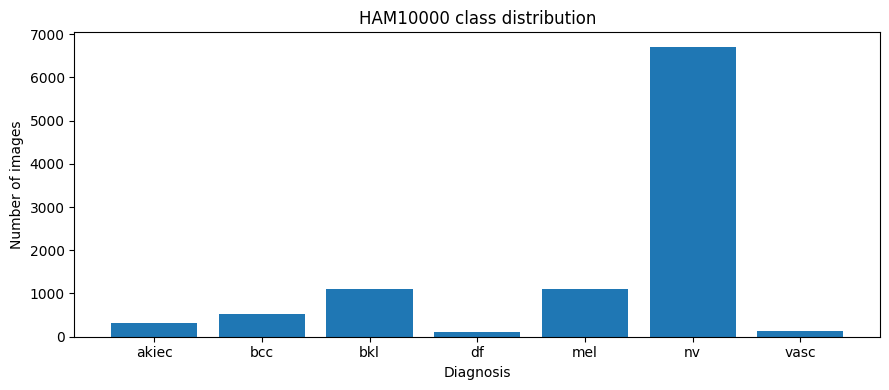

In [8]:

# Class distribution
counts = df["dx"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values)
plt.title("HAM10000 class distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()



## 3. Lesion-level train / validation / test split

HAM10000 can contain multiple images belonging to the same lesion. A plain random image split can leak nearly identical lesion information into multiple splits.

To reduce this risk, the split is grouped by `lesion_id`:

- about 80% train
- about 10% validation
- about 10% test

No `lesion_id` is allowed to appear in more than one split.


In [9]:

# First grouped stratified split: 80% train / 20% temporary.
sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
outer_train_idx, outer_temp_idx = next(
    sgkf_outer.split(df, y=df["label"], groups=df["lesion_id"])
)

train_df = df.iloc[outer_train_idx].reset_index(drop=True)
temp_df = df.iloc[outer_temp_idx].reset_index(drop=True)

# Second grouped stratified split: temporary -> 50% validation / 50% test.
sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED + 1)
val_idx, test_idx = next(
    sgkf_inner.split(temp_df, y=temp_df["label"], groups=temp_df["lesion_id"])
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

def show_split(name, part):
    print(f"{name}: {len(part)} images | {part['lesion_id'].nunique()} unique lesions")
    print(part["dx"].value_counts(normalize=True).reindex(CLASS_NAMES).fillna(0).round(4).to_dict())

show_split("Train", train_df)
show_split("Validation", val_df)
show_split("Test", test_df)

train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)

print("Lesion leakage check: PASSED")


Train: 8001 images | 5975 unique lesions
{'akiec': 0.0324, 'bcc': 0.0517, 'bkl': 0.1117, 'df': 0.0116, 'mel': 0.1114, 'nv': 0.6677, 'vasc': 0.0135}
Validation: 1006 images | 748 unique lesions
{'akiec': 0.0239, 'bcc': 0.0606, 'bkl': 0.0934, 'df': 0.008, 'mel': 0.1183, 'nv': 0.6779, 'vasc': 0.0179}
Test: 1008 images | 747 unique lesions
{'akiec': 0.0437, 'bcc': 0.0387, 'bkl': 0.1101, 'df': 0.0139, 'mel': 0.1022, 'nv': 0.6756, 'vasc': 0.0159}
Lesion leakage check: PASSED



## 4. Image transforms and PyTorch datasets

The training transform adds moderate augmentation. Validation, test, and deep-feature extraction use deterministic preprocessing.

The ResNet normalization uses the standard ImageNet mean/std because the backbone starts from ImageNet pretrained weights.


In [10]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class HAMDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = int(row["label"])
        return image, label

train_ds = HAMDataset(train_df, train_transform)
val_ds = HAMDataset(val_df, eval_transform)
test_ds = HAMDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)
val_loader = DataLoader(
    val_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)
test_loader = DataLoader(
    test_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)

# Class weights are computed only from the training split.
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"].values
)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

print("Class weights:")
for i, w in enumerate(class_weights_np):
    print(f"  {IDX_TO_CLASS[i]}: {w:.4f}")


Class weights:
  akiec: 4.4131
  bcc: 2.7609
  bkl: 1.2785
  df: 12.2903
  mel: 1.2828
  nv: 0.2140
  vasc: 10.5833


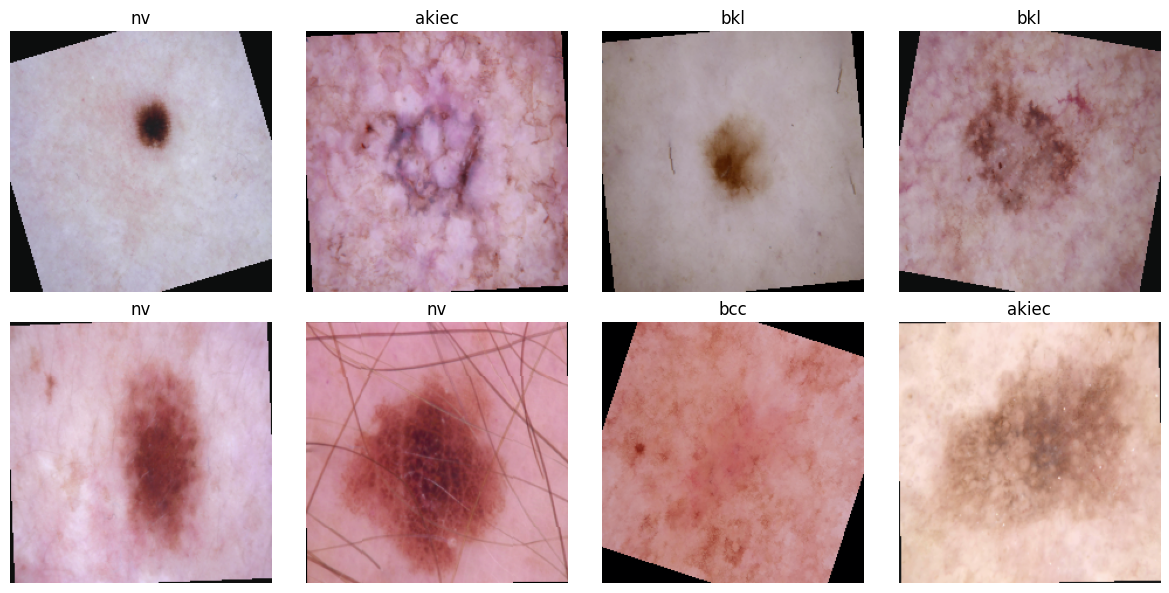

In [11]:

# Show a few training images after augmentation.
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[int(labels[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()



## 5. Reusable early stopping, plots, prediction, and evaluation

Whenever validation loss improves, the checkpoint is saved and the exact message

`Best-Model-saved`

is printed.


In [12]:

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_epoch = -1

    def step(self, val_loss, model, save_path, epoch):
        improved = val_loss < (self.best_loss - self.min_delta)

        if improved:
            self.best_loss = val_loss
            self.counter = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            print("Best-Model-saved")
        else:
            self.counter += 1

        stop = self.counter >= self.patience
        return stop


def plot_history(history, model_name):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title(f"{model_name}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set_title(f"{model_name}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_and_plot(y_true, y_prob, model_name, training_time, testing_time):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = y_prob.argmax(axis=1)

    overall_acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=np.arange(NUM_CLASSES),
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    per_class_acc = np.divide(
        np.diag(cm),
        cm.sum(axis=1),
        out=np.zeros(NUM_CLASSES, dtype=float),
        where=cm.sum(axis=1) != 0,
    )

    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    per_class_auc = np.full(NUM_CLASSES, np.nan, dtype=float)

    for i in range(NUM_CLASSES):
        positives = y_bin[:, i].sum()
        if 0 < positives < len(y_bin):
            per_class_auc[i] = roc_auc_score(y_bin[:, i], y_prob[:, i])

    try:
        macro_auc = roc_auc_score(
            y_true, y_prob, multi_class="ovr", average="macro",
            labels=np.arange(NUM_CLASSES)
        )
    except ValueError:
        macro_auc = np.nan

    metrics_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "per_class_accuracy": per_class_acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc_ovr": per_class_auc,
        "support": support,
    })

    print("=" * 90)
    print(model_name)
    print("=" * 90)
    print(f"Overall accuracy : {overall_acc:.4f}")
    print(f"Macro AUC (OvR) : {macro_auc:.4f}" if np.isfinite(macro_auc) else "Macro AUC (OvR) : unavailable")
    print(f"Training time    : {training_time:.2f} seconds")
    print(f"Testing time     : {testing_time:.2f} seconds")
    print("\nPer-class metrics:")
    display(metrics_df.round(4))

    print("\nClassification report:")
    report = classification_report(
        y_true, y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
    print(report)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm)
    ax.set_title(f"{model_name}: confusion matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticks(np.arange(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)

    threshold = cm.max() / 2 if cm.size else 0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    # ROC curves
    plt.figure(figsize=(9, 7))
    valid_roc_count = 0

    for i, class_name in enumerate(CLASS_NAMES):
        positives = y_bin[:, i].sum()
        if not (0 < positives < len(y_bin)):
            continue

        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={class_auc:.3f})")
        valid_roc_count += 1

    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.title(f"{model_name}: one-vs-rest ROC curves")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    if valid_roc_count:
        plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    macro_precision = np.average(precision, weights=None)
    macro_recall = np.average(recall, weights=None)
    macro_f1 = np.average(f1, weights=None)

    summary = {
        "model": model_name,
        "accuracy": overall_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "macro_auc_ovr": macro_auc,
        "training_time_sec": training_time,
        "testing_time_sec": testing_time,
    }

    safe_name = model_name.lower().replace(" ", "_").replace("/", "_")
    metrics_df.to_csv(WORK_DIR / f"{safe_name}_per_class_metrics.csv", index=False)

    return summary, metrics_df, cm



# Part A — CNN baseline: ResNet50

## 6. Build the transfer-learning model

Stage 1: train only the new classifier head.  
Stage 2: unfreeze `layer4` and fine-tune it with a smaller learning rate.

This is a standard transfer-learning strategy designed to reduce overfitting while adapting ImageNet features to dermoscopic images.


In [13]:

def build_resnet50_model():
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.50),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.30),
        nn.Linear(512, NUM_CLASSES),
    )

    return model


def freeze_for_warmup(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True


def unfreeze_for_finetuning(model):
    for p in model.parameters():
        p.requires_grad = False

    for p in model.layer4.parameters():
        p.requires_grad = True

    for p in model.fc.parameters():
        p.requires_grad = True


def set_resnet_train_mode(model, finetune=False):
    model.train()

    # Frozen early backbone stays in eval mode so frozen BatchNorm running
    # statistics do not drift.
    model.conv1.eval()
    model.bn1.eval()
    model.layer1.eval()
    model.layer2.eval()
    model.layer3.eval()

    if not finetune:
        model.layer4.eval()


cnn_model = build_resnet50_model().to(DEVICE)
freeze_for_warmup(cnn_model)

trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in cnn_model.parameters())

print(cnn_model)
print(f"Total parameters: {total:,}")
print(f"Initially trainable parameters: {trainable:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 


## 7. Train ResNet50 for up to 50 epochs with early stopping

The checkpoint file is `best_resnet50_ham10000.pt`.


Skipping final training batch with batch size 1.
Epoch 01/50 | Train Loss: 1.6704 | Val Loss: 1.4405 | Train Acc: 0.3384 | Val Acc: 0.4940 | LR: 3.00e-04
Best-Model-saved
Skipping final training batch with batch size 1.
Epoch 02/50 | Train Loss: 1.4043 | Val Loss: 1.1968 | Train Acc: 0.4733 | Val Acc: 0.6044 | LR: 3.00e-04
Best-Model-saved
Skipping final training batch with batch size 1.
Epoch 03/50 | Train Loss: 1.3084 | Val Loss: 1.1940 | Train Acc: 0.5349 | Val Acc: 0.5984 | LR: 3.00e-04
Best-Model-saved
Skipping final training batch with batch size 1.
Epoch 04/50 | Train Loss: 1.2590 | Val Loss: 1.0674 | Train Acc: 0.5689 | Val Acc: 0.6262 | LR: 3.00e-04
Best-Model-saved
Skipping final training batch with batch size 1.
Epoch 05/50 | Train Loss: 1.1790 | Val Loss: 1.0002 | Train Acc: 0.6035 | Val Acc: 0.6620 | LR: 3.00e-04
Best-Model-saved

Starting ResNet50 fine-tuning: unfreezing layer4 with smaller learning rate.

Skipping final training batch with batch size 1.
Epoch 06/50 | Tra

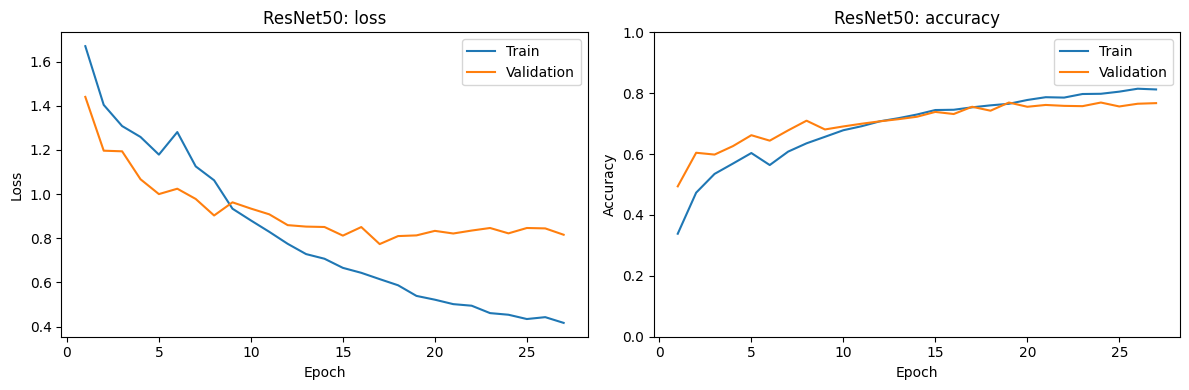

In [14]:

# ============================================================
# CELL 7 - FIXED
# Train ResNet50 for up to 50 epochs with Early Stopping
# ============================================================

def run_cnn_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    finetune=False,
    scaler=None
):
    is_train = optimizer is not None

    # ------------------------------------------
    # Set model mode
    # ------------------------------------------
    if is_train:
        set_resnet_train_mode(model, finetune=finetune)
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    n_seen = 0

    for images, labels in loader:

        # --------------------------------------------------
        # IMPORTANT FIX:
        # BatchNorm1d in ResNet classifier cannot train
        # with batch size = 1.
        # Skip only a singleton final training batch.
        # --------------------------------------------------
        if is_train and images.size(0) < 2:
            print("Skipping final training batch with batch size 1.")
            continue

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        # --------------------------------------------------
        # NEW PyTorch AMP API
        # Fixes torch.cuda.amp deprecation warning
        # --------------------------------------------------
        with torch.set_grad_enabled(is_train):

            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=AMP
            ):
                logits = model(images)

                loss = criterion(
                    logits,
                    labels
                )

            # ----------------------------------------------
            # Backpropagation
            # ----------------------------------------------
            if is_train:

                if AMP:
                    scaler.scale(loss).backward()

                    # Gradient clipping for more stable
                    # fine-tuning
                    scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=2.0
                    )

                    scaler.step(optimizer)
                    scaler.update()

                else:
                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=2.0
                    )

                    optimizer.step()

        # ------------------------------------------
        # Statistics
        # ------------------------------------------
        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        running_correct += (
            predictions == labels
        ).sum().item()

        n_seen += batch_size

    # Safety check
    if n_seen == 0:
        raise RuntimeError(
            "No samples were processed in this epoch."
        )

    epoch_loss = running_loss / n_seen
    epoch_acc = running_correct / n_seen

    return epoch_loss, epoch_acc


# ============================================================
# RESNET50 TRAINING FUNCTION
# ============================================================

def train_resnet50(model):

    # ------------------------------------------
    # Weighted loss for HAM10000 imbalance
    # ------------------------------------------
    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS
    )

    # ------------------------------------------
    # AMP Gradient Scaler
    # New PyTorch API
    # ------------------------------------------
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP
    )

    # ========================================================
    # STAGE 1:
    # Transfer Learning / Classifier Warm-up
    # ========================================================

    freeze_for_warmup(model)

    optimizer = torch.optim.AdamW(
        model.fc.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    # ------------------------------------------
    # Early stopping
    # ------------------------------------------
    stopper = EarlyStopping(
        patience=CNN_PATIENCE,
        min_delta=1e-4
    )

    save_path = (
        WORK_DIR /
        "best_resnet50_ham10000.pt"
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    # ------------------------------------------
    # Training timer
    # ------------------------------------------
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    finetune = False

    # ========================================================
    # MAXIMUM 50 EPOCHS
    # ========================================================

    for epoch in range(
        1,
        CNN_EPOCHS + 1
    ):

        # ====================================================
        # STAGE 2:
        # Fine-tuning starts after warm-up
        # ====================================================

        if epoch == CNN_WARMUP_EPOCHS + 1:

            print("\n" + "=" * 70)
            print(
                "Starting ResNet50 fine-tuning: "
                "unfreezing layer4 with smaller learning rate."
            )
            print("=" * 70 + "\n")

            finetune = True

            unfreeze_for_finetuning(model)

            # Smaller LR for pretrained backbone
            # Higher LR for newly added classifier
            optimizer = torch.optim.AdamW(
                [
                    {
                        "params": model.layer4.parameters(),
                        "lr": 1e-5
                    },
                    {
                        "params": model.fc.parameters(),
                        "lr": 1e-4
                    }
                ],
                weight_decay=1e-4
            )

            scheduler = (
                torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer,
                    mode="min",
                    factor=0.5,
                    patience=3
                )
            )

        # ====================================================
        # TRAIN
        # ====================================================

        train_loss, train_acc = run_cnn_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            finetune=finetune,
            scaler=scaler
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        val_loss, val_acc = run_cnn_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            finetune=finetune,
            scaler=scaler
        )

        # ------------------------------------------
        # Learning-rate scheduler
        # ------------------------------------------
        scheduler.step(val_loss)

        # ------------------------------------------
        # Save history
        # ------------------------------------------
        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )

        current_lr = optimizer.param_groups[0]["lr"]

        # ------------------------------------------
        # Epoch result
        # ------------------------------------------
        print(
            f"Epoch {epoch:02d}/{CNN_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # ====================================================
        # EARLY STOPPING + BEST MODEL SAVE
        # ====================================================

        should_stop = stopper.step(
            val_loss,
            model,
            save_path,
            epoch
        )

        # EarlyStopping class will print:
        # Best-Model-saved

        if should_stop:

            print(
                f"\nEarly stopping activated "
                f"at epoch {epoch}."
            )

            print(
                f"Best epoch: "
                f"{stopper.best_epoch}"
            )

            break

    # ========================================================
    # TRAINING TIME
    # ========================================================

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    training_time = (
        time.perf_counter() -
        start_time
    )

    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    if not save_path.exists():
        raise FileNotFoundError(
            f"Best model checkpoint was not created: "
            f"{save_path}"
        )

    best_state = torch.load(
        save_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        best_state
    )

    print("\n" + "=" * 70)

    print(
        f"Loaded best ResNet50 checkpoint from:\n"
        f"{save_path}"
    )

    print(
        f"Total CNN training time: "
        f"{training_time:.2f} seconds"
    )

    print("=" * 70)

    return model, history, training_time


# ============================================================
# START TRAINING
# ============================================================

cnn_model, cnn_history, cnn_training_time = train_resnet50(
    cnn_model
)

# ============================================================
# LOSS + ACCURACY CURVES
# ============================================================

plot_history(
    cnn_history,
    "ResNet50"
)



## 8. Evaluate the CNN baseline


/tmp/ipykernel_58/1859077683.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):


ResNet50
Overall accuracy : 0.7589
Macro AUC (OvR) : unavailable
Training time    : 1903.44 seconds
Testing time     : 9.54 seconds

Per-class metrics:


,class,per_class_accuracy,precision,recall,f1_score,auc_ovr,support
0,akiec,0.7727,0.4857,0.7727,0.5965,0.9486,44
1,bcc,0.4872,0.4524,0.4872,0.4691,0.9198,39
2,bkl,0.5856,0.5556,0.5856,0.5702,0.9059,111
3,df,0.3571,0.3125,0.3571,0.3333,0.9016,14
4,mel,0.6117,0.4345,0.6117,0.5081,0.8728,103
5,nv,0.8326,0.9387,0.8326,0.8825,0.9337,681
6,vasc,0.7500,0.8571,0.7500,0.8000,0.9940,16



Classification report:
              precision    recall  f1-score   support

       akiec     0.4857    0.7727    0.5965        44
         bcc     0.4524    0.4872    0.4691        39
         bkl     0.5556    0.5856    0.5702       111
          df     0.3125    0.3571    0.3333        14
         mel     0.4345    0.6117    0.5081       103
          nv     0.9387    0.8326    0.8825       681
        vasc     0.8571    0.7500    0.8000        16

    accuracy                         0.7589      1008
   macro avg     0.5766    0.6281    0.5942      1008
weighted avg     0.7964    0.7589    0.7724      1008



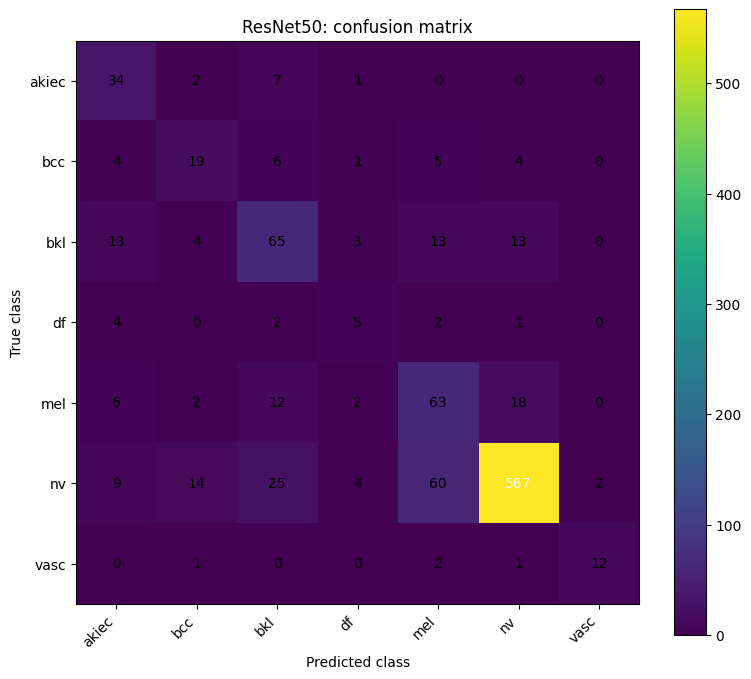

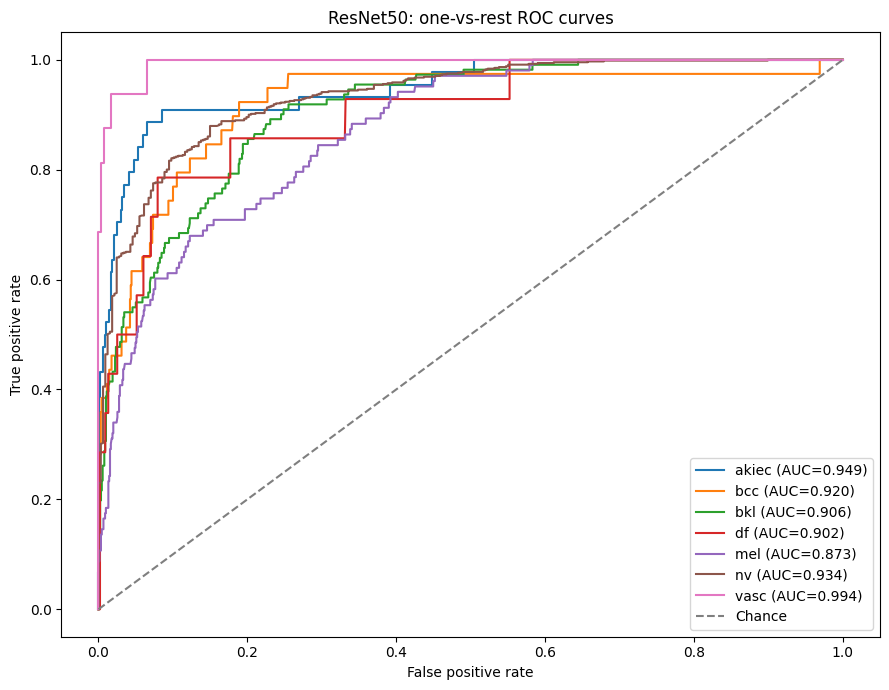

In [15]:

@torch.no_grad()
def predict_cnn(model, loader):
    model.eval()

    all_y = []
    all_prob = []

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            logits = model(images)

        prob = torch.softmax(logits, dim=1)

        all_y.append(labels.numpy())
        all_prob.append(prob.cpu().numpy())

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    testing_time = time.perf_counter() - start

    return np.concatenate(all_y), np.concatenate(all_prob), testing_time


cnn_y_true, cnn_y_prob, cnn_testing_time = predict_cnn(cnn_model, test_loader)

cnn_summary, cnn_metrics_df, cnn_cm = evaluate_and_plot(
    cnn_y_true, cnn_y_prob,
    model_name="ResNet50",
    training_time=cnn_training_time,
    testing_time=cnn_testing_time
)



# Part B — Convert ResNet50 deep features to graphs

## 9. Extract a spatial deep-feature map

We extract the output of `layer4[-1].bn2`, which is a **512-channel spatial map** near the end of ResNet50.

For a 224×224 input, this map is normally 7×7. Therefore each image becomes:

- 49 graph nodes
- one node per 7×7 spatial location
- node feature = 512 deep CNN features + normalized row + normalized column
- up/down/left/right edges only
- self-loops included

This is the same graph topology used in the supplied sample notebook, simply applied to a CNN feature grid instead of the original 8×8 digit pixel grid.


In [26]:

# Deterministic datasets for deep feature extraction.
feature_train_ds = HAMDataset(train_df, eval_transform)
feature_val_ds = HAMDataset(val_df, eval_transform)
feature_test_ds = HAMDataset(test_df, eval_transform)

feature_train_loader = DataLoader(
    feature_train_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)
feature_val_loader = DataLoader(
    feature_val_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)
feature_test_loader = DataLoader(
    feature_test_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=AMP,
    persistent_workers=NUM_WORKERS > 0
)


@torch.no_grad()
def extract_graph_node_features(model, loader, cache_path=None):
    if cache_path is not None and cache_path.exists():
        print("Loading cached deep graph features:", cache_path)
        obj = torch.load(cache_path, map_location="cpu")
        return obj["x"], obj["y"], obj["h"], obj["w"], obj["seconds"]

    model.eval()

    captured = {}

    def hook_fn(module, inputs, output):
        captured["feature_map"] = output.detach()

    handle = model.layer4[-1].bn2.register_forward_hook(hook_fn)

    all_x = []
    all_y = []

    spatial_h = None
    spatial_w = None

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        captured.clear()

        with torch.cuda.amp.autocast(enabled=AMP):
            _ = model(images)

        fmap = F.relu(captured["feature_map"])  # [B, 512, H, W]
        B, C, H, W = fmap.shape

        if spatial_h is None:
            spatial_h, spatial_w = H, W

            # EXACT positional style from the supplied sample:
            # row index / H and column index / W
            row_pos = torch.tensor(
                [r for r in range(H) for c in range(W)],
                device=fmap.device,
                dtype=torch.float32
            ) / H

            col_pos = torch.tensor(
                [c for r in range(H) for c in range(W)],
                device=fmap.device,
                dtype=torch.float32
            ) / W

            pos = torch.stack([row_pos, col_pos], dim=1)  # [H*W, 2]
        else:
            assert H == spatial_h and W == spatial_w

        # [B, C, H, W] -> [B, H*W, C]
        nodes = fmap.permute(0, 2, 3, 1).reshape(B, H * W, C).float()

        # Normalize deep channel vector at each spatial node.
        nodes = F.normalize(nodes, p=2, dim=-1)

        # Append the same row/column position features used by the sample notebook.
        pos_batch = pos.unsqueeze(0).expand(B, -1, -1)
        nodes = torch.cat([nodes, pos_batch], dim=-1)

        # Store half precision on CPU to reduce RAM/disk usage.
        all_x.append(nodes.half().cpu())
        all_y.append(labels.long().cpu())

    handle.remove()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    x = torch.cat(all_x, dim=0)
    y = torch.cat(all_y, dim=0)

    if cache_path is not None:
        torch.save({
            "x": x,
            "y": y,
            "h": spatial_h,
            "w": spatial_w,
            "seconds": elapsed,
        }, cache_path)

    return x, y, spatial_h, spatial_w, elapsed


train_cache = WORK_DIR / "resnet50_train_graph_features.pt" if FEATURE_CACHE else None
val_cache = WORK_DIR / "resnet50_val_graph_features.pt" if FEATURE_CACHE else None
test_cache = WORK_DIR / "resnet50_test_graph_features.pt" if FEATURE_CACHE else None

Xg_train, yg_train, GH, GW, feature_train_time = extract_graph_node_features(
    cnn_model, feature_train_loader, train_cache
)
Xg_val, yg_val, GH2, GW2, feature_val_time = extract_graph_node_features(
    cnn_model, feature_val_loader, val_cache
)
Xg_test, yg_test, GH3, GW3, feature_test_time = extract_graph_node_features(
    cnn_model, feature_test_loader, test_cache
)

assert (GH, GW) == (GH2, GW2) == (GH3, GW3)

print("Train graph features:", Xg_train.shape)
print("Validation graph features:", Xg_val.shape)
print("Test graph features:", Xg_test.shape)
print(f"Spatial graph grid: {GH} x {GW} = {GH*GW} nodes/image")
print("Node feature dimension:", Xg_train.shape[-1])
print(f"Feature extraction time (train): {feature_train_time:.2f}s")
print(f"Feature extraction time (val)  : {feature_val_time:.2f}s")
print(f"Feature extraction time (test) : {feature_test_time:.2f}s")


Loading cached deep graph features: /kaggle/working/resnet50_train_graph_features.pt
Loading cached deep graph features: /kaggle/working/resnet50_val_graph_features.pt
Loading cached deep graph features: /kaggle/working/resnet50_test_graph_features.pt
Train graph features: torch.Size([8001, 49, 514])
Validation graph features: torch.Size([1006, 49, 514])
Test graph features: torch.Size([1008, 49, 514])
Spatial graph grid: 7 x 7 = 49 nodes/image
Node feature dimension: 514
Feature extraction time (train): 40.77s
Feature extraction time (val)  : 5.47s
Feature extraction time (test) : 5.61s



## 10. Build the fixed 4-neighbor grid graph

This mirrors the supplied notebook:

```text
for each grid location:
    connect down neighbor if it exists
    connect right neighbor if it exists
```

Because NetworkX `Graph` is undirected in the sample, both message-passing directions are included here. Self-loops are also explicitly included.


Nodes per image: 49
Directed edges including explicit self-loops: 217


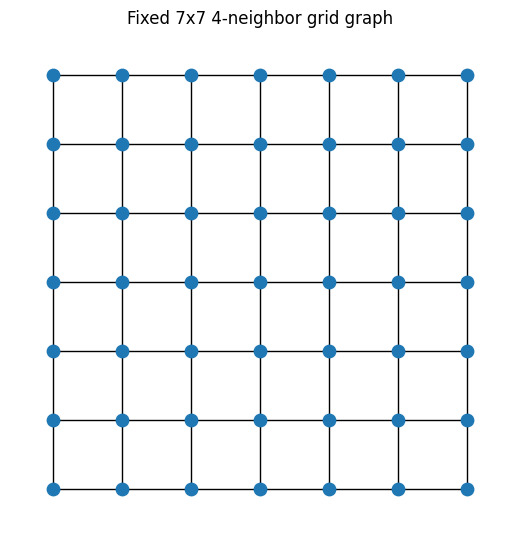

In [27]:

def node_id(r, c, width):
    return r * width + c


def build_grid_edge_index(H, W, include_self_loops=True):
    edges = []

    for r in range(H):
        for c in range(W):
            u = node_id(r, c, W)

            if r + 1 < H:
                v = node_id(r + 1, c, W)
                edges.append((u, v))
                edges.append((v, u))

            if c + 1 < W:
                v = node_id(r, c + 1, W)
                edges.append((u, v))
                edges.append((v, u))

            if include_self_loops:
                edges.append((u, u))

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index


EDGE_INDEX = build_grid_edge_index(GH, GW, include_self_loops=True)

print("Nodes per image:", GH * GW)
print("Directed edges including explicit self-loops:", EDGE_INDEX.shape[1])

# Visualize exactly the same type of grid graph as in the sample notebook.
G = nx.Graph()
G.add_nodes_from(range(GH * GW))

for r in range(GH):
    for c in range(GW):
        if r + 1 < GH:
            G.add_edge(node_id(r, c, GW), node_id(r + 1, c, GW))
        if c + 1 < GW:
            G.add_edge(node_id(r, c, GW), node_id(r, c + 1, GW))

pos = {node_id(r, c, GW): (c, -r) for r in range(GH) for c in range(GW)}

plt.figure(figsize=(5, 5))
nx.draw(G, pos, node_size=80)
plt.title(f"Fixed {GH}x{GW} 4-neighbor grid graph")
plt.show()



## 11. PyTorch Geometric graph datasets


In [28]:

class DeepFeatureGraphDataset(Dataset):
    def __init__(self, node_features, labels, edge_index):
        self.node_features = node_features
        self.labels = labels
        self.edge_index = edge_index

    def __len__(self):
        return self.labels.numel()

    def __getitem__(self, idx):
        return Data(
            x=self.node_features[idx].float(),
            edge_index=self.edge_index,
            y=self.labels[idx].view(1),
        )


graph_train_ds = DeepFeatureGraphDataset(Xg_train, yg_train, EDGE_INDEX)
graph_val_ds = DeepFeatureGraphDataset(Xg_val, yg_val, EDGE_INDEX)
graph_test_ds = DeepFeatureGraphDataset(Xg_test, yg_test, EDGE_INDEX)

graph_train_loader = GeoDataLoader(
    graph_train_ds, batch_size=GNN_BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=AMP
)
graph_val_loader = GeoDataLoader(
    graph_val_ds, batch_size=GNN_BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=AMP
)
graph_test_loader = GeoDataLoader(
    graph_test_ds, batch_size=GNN_BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=AMP
)

sample_batch = next(iter(graph_train_loader))
print(sample_batch)
print("Batched x:", sample_batch.x.shape)
print("Batched edge_index:", sample_batch.edge_index.shape)
print("Batched graph labels:", sample_batch.y.shape)


DataBatch(x=[3136, 514], edge_index=[2, 13888], y=[64], batch=[3136], ptr=[65])
Batched x: torch.Size([3136, 514])
Batched edge_index: torch.Size([2, 13888])
Batched graph labels: torch.Size([64])



# Part C — GATv2

## 12. GATv2 graph classifier

The graph-level readout is **mean pooling**, matching the sample notebook's mean readout concept.


In [29]:

NODE_FEATURE_DIM = Xg_train.shape[-1]

class GATv2Net(nn.Module):
    def __init__(self, in_features, num_classes=NUM_CLASSES):
        super().__init__()

        self.conv1 = GATv2Conv(
            in_features, 64,
            heads=4, concat=True,
            dropout=0.25,
            add_self_loops=False
        )
        self.bn1 = nn.BatchNorm1d(64 * 4)

        self.conv2 = GATv2Conv(
            64 * 4, 64,
            heads=4, concat=True,
            dropout=0.25,
            add_self_loops=False
        )
        self.bn2 = nn.BatchNorm1d(64 * 4)

        self.conv3 = GATv2Conv(
            64 * 4, 128,
            heads=1, concat=False,
            dropout=0.25,
            add_self_loops=False
        )
        self.bn3 = nn.BatchNorm1d(128)

        self.classifier = nn.Sequential(
            nn.Dropout(0.45),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        graph_embedding = global_mean_pool(x, batch)
        return self.classifier(graph_embedding)

    def auxiliary_loss(self):
        return torch.tensor(0.0, device=next(self.parameters()).device)


gatv2_model = GATv2Net(NODE_FEATURE_DIM).to(DEVICE)
print(gatv2_model)
print("Parameters:", f"{sum(p.numel() for p in gatv2_model.parameters()):,}")


GATv2Net(
  (conv1): GATv2Conv(514, 64, heads=4)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATv2Conv(256, 64, heads=4)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GATv2Conv(256, 128, heads=1)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Dropout(p=0.45, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=7, bias=True)
  )
)
Parameters: 472,327



## 13. Generic GNN training and prediction functions

Both GNNs:

- train for up to 50 epochs
- use weighted cross-entropy
- use AdamW
- use learning-rate reduction
- use dropout and weight decay
- use early stopping
- save the best validation checkpoint
- print `Best-Model-saved`


In [35]:

def maybe_load_pretrained_gnn(model, model_name):
    path = PRETRAINED_GNN_PATHS.get(model_name)

    if path is None:
        print(f"{model_name}: no external pretrained GNN checkpoint supplied; "
              "training on transferred ResNet50 features.")
        return model

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Pretrained {model_name} checkpoint not found: {path}")

    state = torch.load(path, map_location=DEVICE)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"Loaded pretrained {model_name} checkpoint: {path}")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
    return model


def run_gnn_epoch(model, loader, criterion, optimizer=None, aux_weight=0.0):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        y = batch.y.view(-1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(batch.x, batch.edge_index, batch.batch)
            cls_loss = criterion(logits, y)
            loss = cls_loss + aux_weight * model.auxiliary_loss()

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                optimizer.step()

        n = y.numel()
        total_loss += loss.item() * n
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_graphs += n

    return total_loss / total_graphs, total_correct / total_graphs


def train_gnn(
    model,
    model_name,
    train_loader,
    val_loader,
    max_epochs=GNN_EPOCHS,
    patience=GNN_PATIENCE,
    lr=2e-4,
    aux_weight=0.0,
):
    model = maybe_load_pretrained_gnn(model, model_name)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    stopper = EarlyStopping(patience=patience, min_delta=1e-4)
    save_path = WORK_DIR / f"best_{model_name.lower()}_ham10000.pt"

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_gnn_epoch(
            model, train_loader, criterion,
            optimizer=optimizer,
            aux_weight=aux_weight
        )

        val_loss, val_acc = run_gnn_epoch(
            model, val_loader, criterion,
            optimizer=None,
            aux_weight=aux_weight
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"{model_name} | Epoch {epoch:02d}/{max_epochs} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"train acc {train_acc:.4f} | val acc {val_acc:.4f} | "
            f"lr {current_lr:.2e}"
        )

        should_stop = stopper.step(val_loss, model, save_path, epoch)

        if should_stop:
            print(f"{model_name}: early stopping at epoch {epoch}. "
                  f"Best epoch: {stopper.best_epoch}")
            break

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    training_time = time.perf_counter() - start

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"Loaded best {model_name} checkpoint from: {save_path}")

    return model, history, training_time


@torch.no_grad()
def predict_gnn(model, loader):
    model.eval()

    all_y = []
    all_prob = []

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch)
        prob = torch.softmax(logits, dim=1)

        all_y.append(batch.y.view(-1).cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    testing_time = time.perf_counter() - start

    return np.concatenate(all_y), np.concatenate(all_prob), testing_time



## 14. Train GATv2


GATv2: no external pretrained GNN checkpoint supplied; training on transferred ResNet50 features.
GATv2 | Epoch 01/50 | train loss 1.8253 | val loss 1.7658 | train acc 0.2575 | val acc 0.3469 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 02/50 | train loss 1.3998 | val loss 1.5079 | train acc 0.4562 | val acc 0.4732 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 03/50 | train loss 1.1046 | val loss 1.2713 | train acc 0.5368 | val acc 0.5328 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 04/50 | train loss 0.9144 | val loss 1.1313 | train acc 0.5812 | val acc 0.5845 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 05/50 | train loss 0.8062 | val loss 1.1286 | train acc 0.6298 | val acc 0.5885 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 06/50 | train loss 0.7409 | val loss 1.0718 | train acc 0.6539 | val acc 0.5964 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 07/50 | train loss 0.6760 | val loss 1.0432 | train acc 0.6784 | val acc 0.6322 | lr 2.00e-04
Best-Model-saved
GATv2 | Epoch 08/50 | train

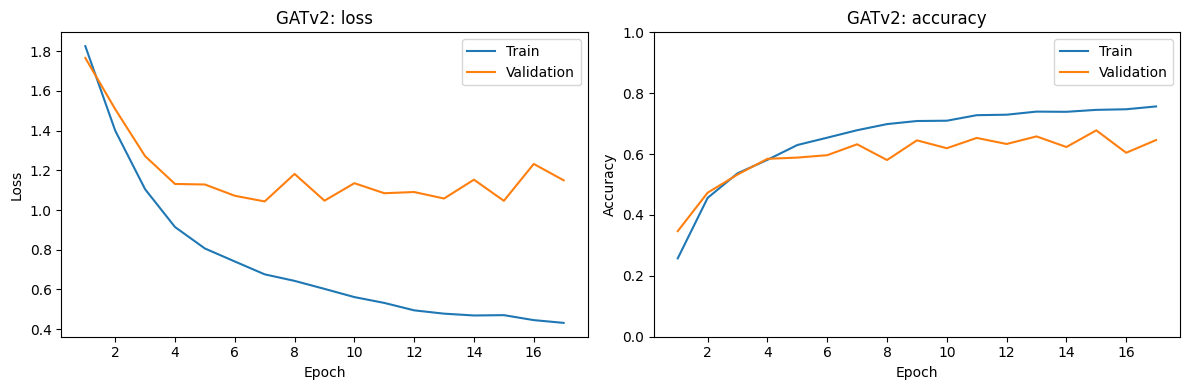

In [31]:

gatv2_model, gatv2_history, gatv2_training_time = train_gnn(
    gatv2_model,
    model_name="GATv2",
    train_loader=graph_train_loader,
    val_loader=graph_val_loader,
    max_epochs=GNN_EPOCHS,
    patience=GNN_PATIENCE,
    lr=2e-4,
    aux_weight=0.0
)

plot_history(gatv2_history, "GATv2")



## 15. Evaluate GATv2


GATv2
Overall accuracy : 0.6657
Macro AUC (OvR) : 0.8588
Training time    : 45.05 seconds
Testing time     : 0.23 seconds

Per-class metrics:


,class,per_class_accuracy,precision,recall,f1_score,auc_ovr,support
0,akiec,0.7727,0.4304,0.7727,0.5528,0.9253,44
1,bcc,0.5641,0.2785,0.5641,0.3729,0.8851,39
2,bkl,0.5495,0.5214,0.5495,0.5351,0.8678,111
3,df,0.3571,0.2000,0.3571,0.2564,0.6467,14
4,mel,0.5340,0.3179,0.5340,0.3986,0.8344,103
5,nv,0.7122,0.9436,0.7122,0.8117,0.9084,681
6,vasc,0.5625,0.4286,0.5625,0.4865,0.9441,16



Classification report:
              precision    recall  f1-score   support

       akiec     0.4304    0.7727    0.5528        44
         bcc     0.2785    0.5641    0.3729        39
         bkl     0.5214    0.5495    0.5351       111
          df     0.2000    0.3571    0.2564        14
         mel     0.3179    0.5340    0.3986       103
          nv     0.9436    0.7122    0.8117       681
        vasc     0.4286    0.5625    0.4865        16

    accuracy                         0.6657      1008
   macro avg     0.4458    0.5789    0.4877      1008
weighted avg     0.7665    0.6657    0.6979      1008



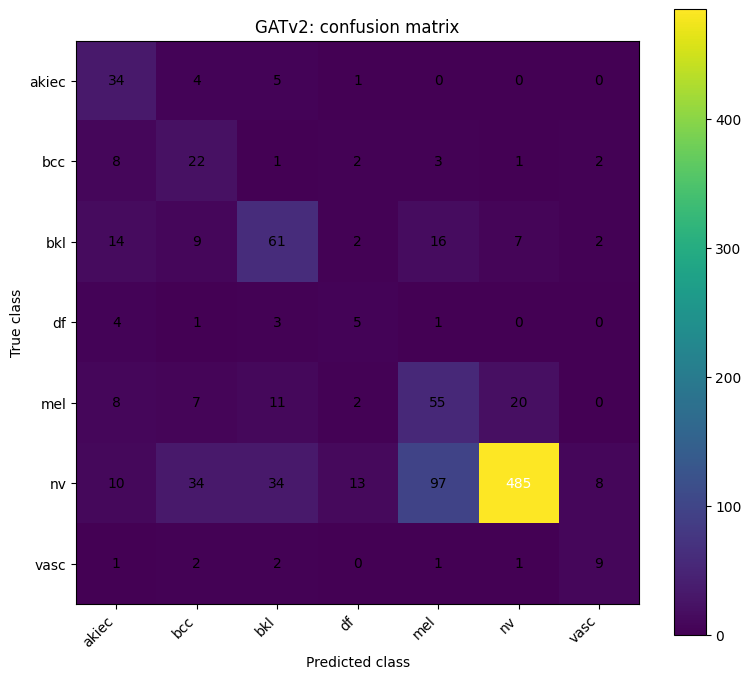

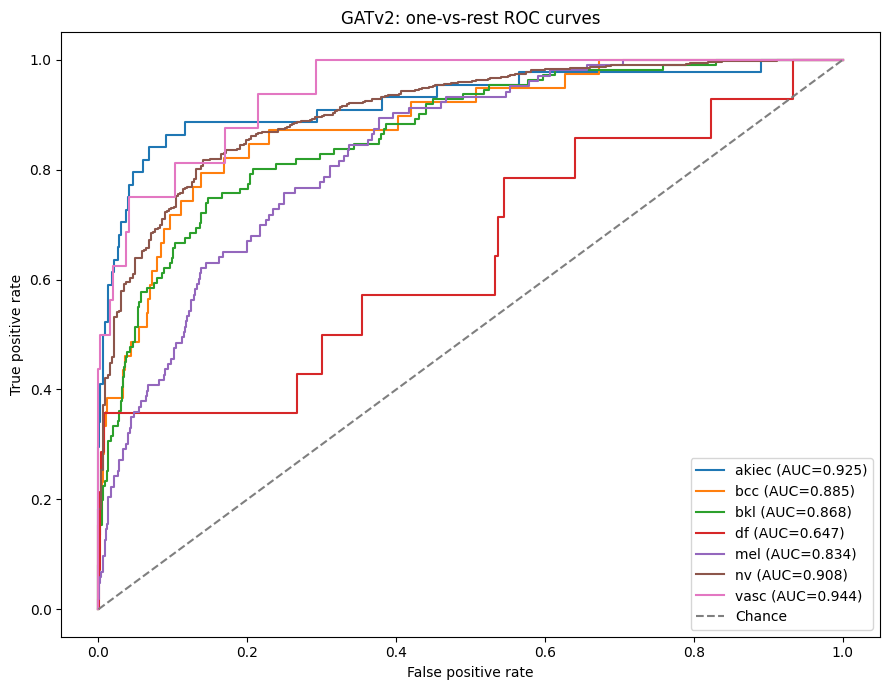

In [32]:

gatv2_y_true, gatv2_y_prob, gatv2_testing_time = predict_gnn(
    gatv2_model, graph_test_loader
)

gatv2_summary, gatv2_metrics_df, gatv2_cm = evaluate_and_plot(
    gatv2_y_true,
    gatv2_y_prob,
    model_name="GATv2",
    training_time=gatv2_training_time,
    testing_time=gatv2_testing_time
)



# Part D — SuperGAT

## 16. SuperGAT graph classifier

SuperGAT adds a self-supervised attention objective. Its auxiliary attention loss is combined with the 7-class classification loss during training.


In [38]:

class SuperGATNet(nn.Module):
    def __init__(self, in_features, num_classes=NUM_CLASSES):
        super().__init__()

        self.conv1 = SuperGATConv(
            in_features, 64,
            heads=4, concat=True,
            dropout=0.25,
            add_self_loops=False,
            attention_type="MX",
            neg_sample_ratio=0.5,
            edge_sample_ratio=1.0,
            is_undirected=True
        )
        self.bn1 = nn.BatchNorm1d(64 * 4)

        self.conv2 = SuperGATConv(
            64 * 4, 64,
            heads=4, concat=True,
            dropout=0.25,
            add_self_loops=False,
            attention_type="MX",
            neg_sample_ratio=0.5,
            edge_sample_ratio=1.0,
            is_undirected=True
        )
        self.bn2 = nn.BatchNorm1d(64 * 4)

        self.conv3 = SuperGATConv(
            64 * 4, 128,
            heads=1, concat=False,
            dropout=0.25,
            add_self_loops=False,
            attention_type="MX",
            neg_sample_ratio=0.5,
            edge_sample_ratio=1.0,
            is_undirected=True
        )
        self.bn3 = nn.BatchNorm1d(128)

        self.classifier = nn.Sequential(
            nn.Dropout(0.45),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index, batch=batch)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv2(x, edge_index, batch=batch)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv3(x, edge_index, batch=batch)
        x = self.bn3(x)
        x = F.elu(x)

        graph_embedding = global_mean_pool(x, batch)
        return self.classifier(graph_embedding)

    def auxiliary_loss(self):
        if not self.training:
            return torch.tensor(0.0, device=next(self.parameters()).device)

        return (
            self.conv1.get_attention_loss()
            + self.conv2.get_attention_loss()
            + self.conv3.get_attention_loss()
        )


supergat_model = SuperGATNet(NODE_FEATURE_DIM).to(DEVICE)
print(supergat_model)
print("Parameters:", f"{sum(p.numel() for p in supergat_model.parameters()):,}")


SuperGATNet(
  (conv1): SuperGATConv(514, 64, heads=4, type=MX)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SuperGATConv(256, 64, heads=4, type=MX)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): SuperGATConv(256, 128, heads=1, type=MX)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Dropout(p=0.45, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=7, bias=True)
  )
)
Parameters: 241,799



## 17. Train SuperGAT


SuperGAT: no external pretrained GNN checkpoint supplied; training on transferred ResNet50 features.
SuperGAT | Epoch 01/50 | train loss 0.7564 | val loss 1.0230 | train acc 0.7185 | val acc 0.6441 | lr 2.00e-04
Best-Model-saved
SuperGAT | Epoch 02/50 | train loss 0.7220 | val loss 0.9923 | train acc 0.7330 | val acc 0.6630 | lr 2.00e-04
Best-Model-saved
SuperGAT | Epoch 03/50 | train loss 0.6987 | val loss 1.2467 | train acc 0.7187 | val acc 0.5984 | lr 2.00e-04
SuperGAT | Epoch 04/50 | train loss 0.6827 | val loss 1.2467 | train acc 0.7287 | val acc 0.5865 | lr 2.00e-04
SuperGAT | Epoch 05/50 | train loss 0.6296 | val loss 1.1639 | train acc 0.7484 | val acc 0.6183 | lr 2.00e-04
SuperGAT | Epoch 06/50 | train loss 0.6211 | val loss 1.1068 | train acc 0.7443 | val acc 0.6461 | lr 1.00e-04
SuperGAT | Epoch 07/50 | train loss 0.5867 | val loss 1.2386 | train acc 0.7555 | val acc 0.6103 | lr 1.00e-04
SuperGAT | Epoch 08/50 | train loss 0.5740 | val loss 1.2479 | train acc 0.7595 | val ac

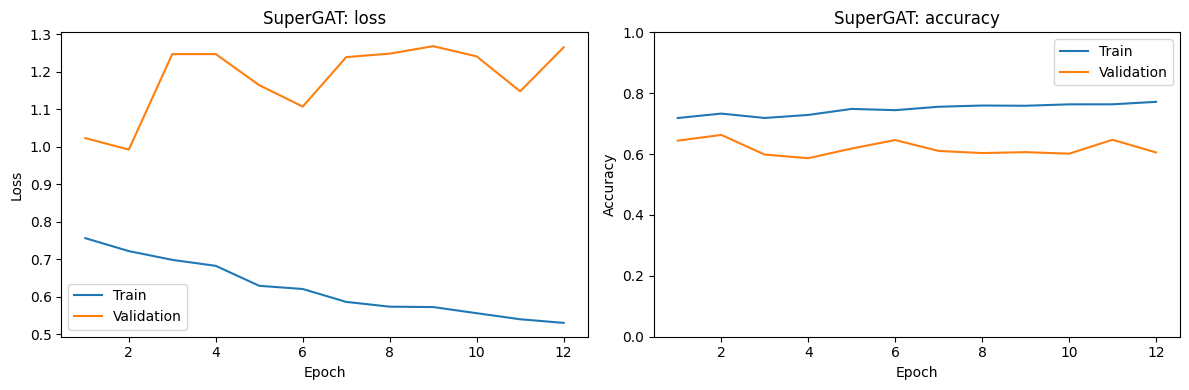

In [36]:

supergat_model, supergat_history, supergat_training_time = train_gnn(
    supergat_model,
    model_name="SuperGAT",
    train_loader=graph_train_loader,
    val_loader=graph_val_loader,
    max_epochs=GNN_EPOCHS,
    patience=GNN_PATIENCE,
    lr=2e-4,
    aux_weight=0.01
)

plot_history(supergat_history, "SuperGAT")



## 18. Evaluate SuperGAT


SuperGAT
Overall accuracy : 0.1022
Macro AUC (OvR) : 0.4582
Training time    : 573.79 seconds
Testing time     : 0.24 seconds

Per-class metrics:


,class,per_class_accuracy,precision,recall,f1_score,auc_ovr,support
0,akiec,0.0,0.0000,0.0,0.0000,0.4349,44
1,bcc,0.0,0.0000,0.0,0.0000,0.3724,39
2,bkl,0.0,0.0000,0.0,0.0000,0.5667,111
3,df,0.0,0.0000,0.0,0.0000,0.5698,14
4,mel,1.0,0.1022,1.0,0.1854,0.3293,103
5,nv,0.0,0.0000,0.0,0.0000,0.4450,681
6,vasc,0.0,0.0000,0.0,0.0000,0.4892,16



Classification report:
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        44
         bcc     0.0000    0.0000    0.0000        39
         bkl     0.0000    0.0000    0.0000       111
          df     0.0000    0.0000    0.0000        14
         mel     0.1022    1.0000    0.1854       103
          nv     0.0000    0.0000    0.0000       681
        vasc     0.0000    0.0000    0.0000        16

    accuracy                         0.1022      1008
   macro avg     0.0146    0.1429    0.0265      1008
weighted avg     0.0104    0.1022    0.0189      1008



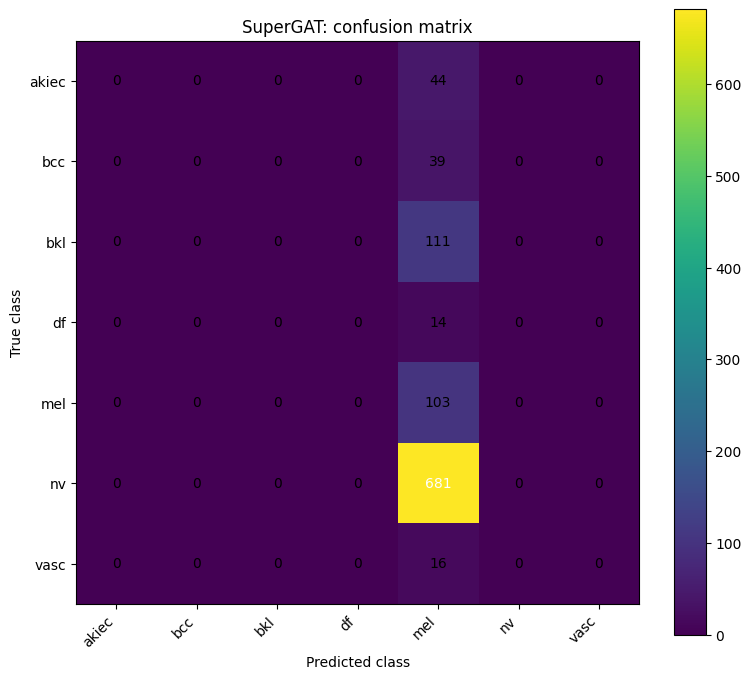

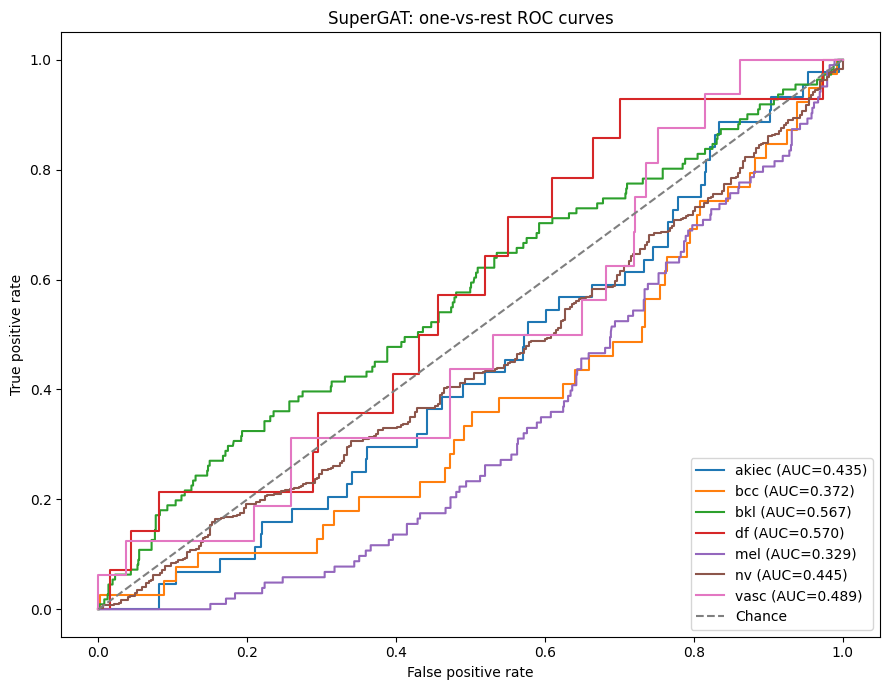

In [39]:

supergat_y_true, supergat_y_prob, supergat_testing_time = predict_gnn(
    supergat_model, graph_test_loader
)

supergat_summary, supergat_metrics_df, supergat_cm = evaluate_and_plot(
    supergat_y_true,
    supergat_y_prob,
    model_name="SuperGAT",
    training_time=supergat_training_time,
    testing_time=supergat_testing_time
)



# Part E — Final comparison


In [40]:

comparison = pd.DataFrame([
    cnn_summary,
    gatv2_summary,
    supergat_summary,
])

display(comparison.round(4))

comparison.to_csv(WORK_DIR / "model_comparison.csv", index=False)

print("\nDeep-feature extraction time is reported separately because it is a transfer step shared by the GNN pipeline:")
print(f"Train feature extraction: {feature_train_time:.2f} seconds")
print(f"Val feature extraction  : {feature_val_time:.2f} seconds")
print(f"Test feature extraction : {feature_test_time:.2f} seconds")
print("\nSaved outputs:", WORK_DIR)


,model,accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,training_time_sec,testing_time_sec
0,ResNet50,0.7589,0.5766,0.6281,0.5942,NaN,1903.4394,9.5403
1,GATv2,0.6657,0.4458,0.5789,0.4877,0.8588,45.0512,0.2344
2,SuperGAT,0.1022,0.0146,0.1429,0.0265,0.4582,573.7936,0.2373



Deep-feature extraction time is reported separately because it is a transfer step shared by the GNN pipeline:
Train feature extraction: 40.77 seconds
Val feature extraction  : 5.47 seconds
Test feature extraction : 5.61 seconds

Saved outputs: /kaggle/working



## 19. Optional: inspect predictions


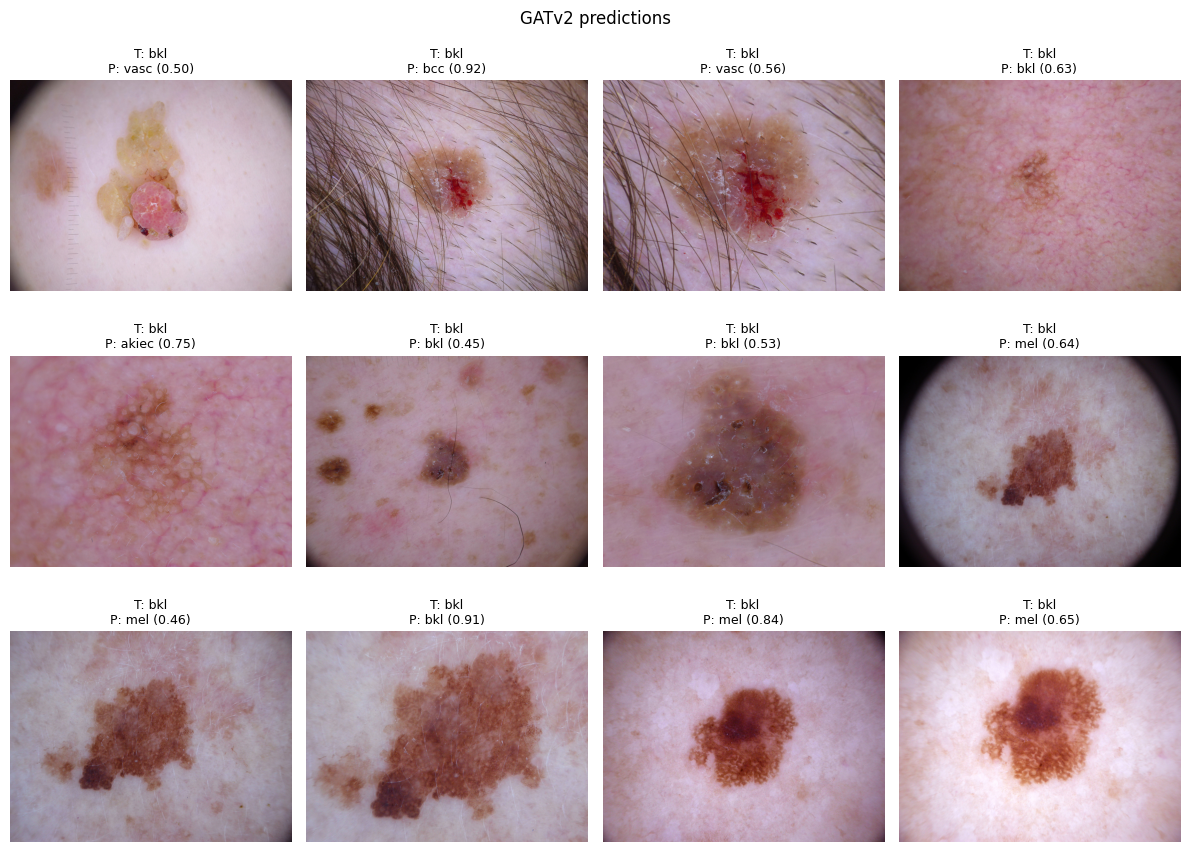

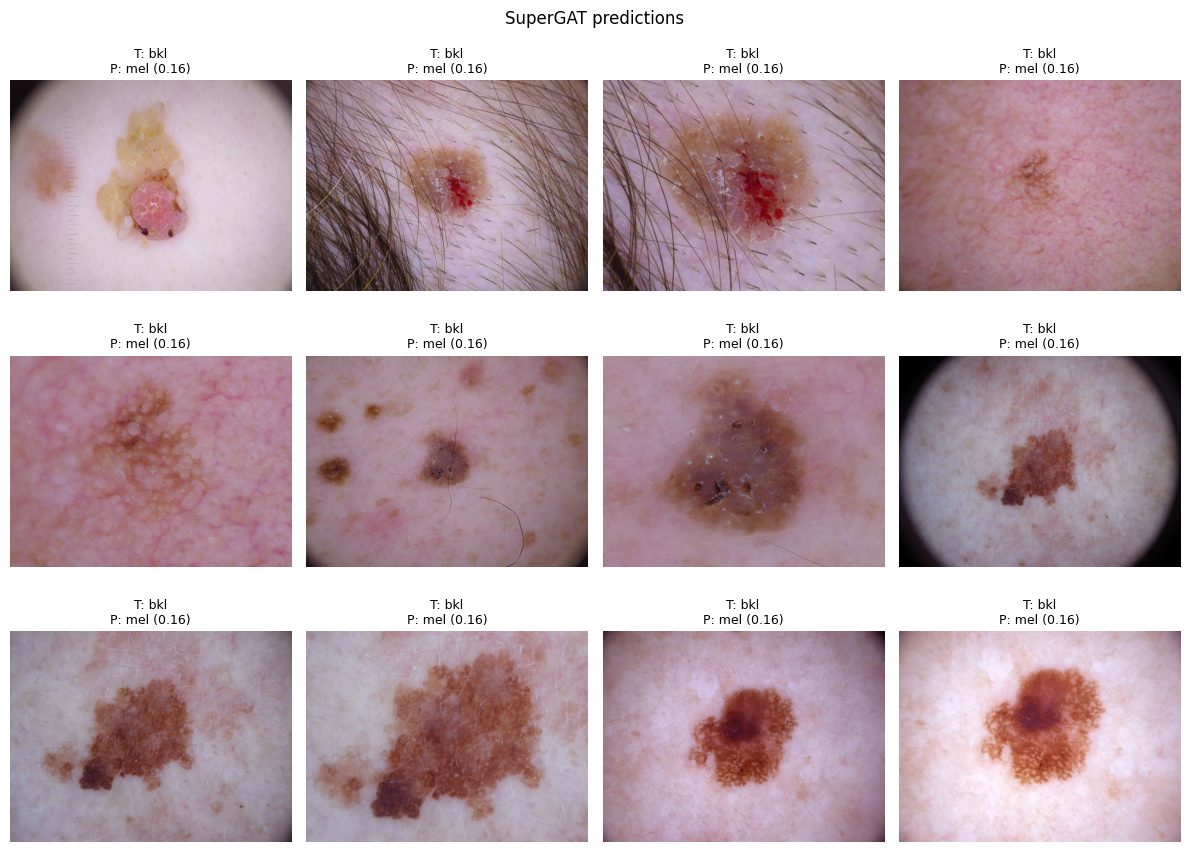

In [41]:

def show_predictions(frame, y_true, y_prob, title, n=12):
    y_pred = y_prob.argmax(axis=1)
    n = min(n, len(frame))

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()

    for i in range(n):
        image = Image.open(frame.iloc[i]["path"]).convert("RGB")
        axes[i].imshow(image)

        true_name = IDX_TO_CLASS[int(y_true[i])]
        pred_name = IDX_TO_CLASS[int(y_pred[i])]
        confidence = float(y_prob[i, y_pred[i]])

        axes[i].set_title(
            f"T: {true_name}\nP: {pred_name} ({confidence:.2f})",
            fontsize=9
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_predictions(test_df, gatv2_y_true, gatv2_y_prob, "GATv2 predictions")
show_predictions(test_df, supergat_y_true, supergat_y_prob, "SuperGAT predictions")
